# Quickstart

## 1. Load the LongMemEval dataset from the Hub

In [1]:
import os
from dotenv import find_dotenv, load_dotenv

# walks up from the cwd until it finds a .env
load_dotenv(find_dotenv(usecwd=True))
HF_TOKEN = os.environ["HUGGINGFACE_TOKEN"]

In [2]:
from huggingface_hub import hf_hub_download

DATA_PATH = hf_hub_download(
    repo_id="xiaowu0162/longmemeval-cleaned",
    filename="longmemeval_oracle.json",
    repo_type="dataset",
    token=HF_TOKEN,
)

DATA_PATH

/home/ssubrahmanya/summary-mem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/ssubrahmanya/.cache/huggingface/hub/datasets--xiaowu0162--longmemeval-cleaned/snapshots/98d7416c24c778c2fee6e6f3006e7a073259d48f/longmemeval_oracle.json'

In [3]:
import json

dataset = json.loads(open(DATA_PATH).read())
len(dataset)

500

## 2. Pick a random sample & describe it

In [4]:
import random

sample = random.choice(dataset)
sample["question_id"]

'945e3d21'

In [5]:
sessions = sample["haystack_sessions"]
turns_per_session = [len(s) for s in sessions]

print("question_id     :", sample["question_id"])
print("question_type   :", sample["question_type"])
print("question_date   :", sample.get("question_date"))
print("num_sessions    :", len(sessions))
print("turns/session   :", turns_per_session)
print("total_turns     :", sum(turns_per_session))
print("min/avg/max     :", min(turns_per_session), sum(turns_per_session) / len(sessions), max(turns_per_session))
print("question        :", sample["question"])
print("gold answer     :", sample["answer"])

question_id     : 945e3d21
question_type   : knowledge-update
question_date   : 2023/12/25 (Mon) 05:30
num_sessions    : 2
turns/session   : [12, 12]
total_turns     : 24
min/avg/max     : 12 12.0 12
question        : How often do I attend yoga classes to help with my anxiety?
gold answer     : Three times a week.


## 3. Run summary-mem on the sample

### 3.1 Load & instantiate

In [6]:
from summary_mem.clients import get_chat_client
from summary_mem.eval import MemoryEvaluator

client = get_chat_client()
evaluator = MemoryEvaluator(
    client,
    conversation_id=sample["question_id"],
    db_path="sample_memory.db",
)

### 3.2 Index the sessions into memory

In [7]:
evaluator.index(sample["haystack_sessions"], sample.get("haystack_dates"))
evaluator.memory.recall(sample["question_id"])

{'assistant': "The assistant is designed to help users prioritize their work tasks and support them in managing stress and mental health. They offer guidance on task prioritization using the Eisenhower Matrix, assisting users in categorizing tasks based on urgency and importance. The assistant encourages users to share their tasks and provides recommendations for handling them effectively, including the creation of detailed schedules.\n\nThe assistant emphasizes the importance of self-care and mindfulness practices. They suggest various stress-reducing apps and meditation techniques, such as mindfulness meditation, loving-kindness meditation, body scan, and 4-7-8 breathing, to help users manage anxiety and improve focus. The assistant also provides journaling prompts and reflection exercises for users exploring childhood trauma and emotional healing, stressing the significance of self-compassion, boundary setting, and seeking professional help.\n\nTo enhance users' understanding of anx

### 3.3 Query with the sample's question

In [8]:
result = evaluator.rag_qa(
    sample["question"],
    question_date=sample.get("question_date"),
    gold_answer=sample["answer"],
)

### 3.4 Compare against the gold answer

In [9]:
print("Q     :", result.question)
print("GOLD  :", result.gold)
print("MODEL :", result.answer)
print("CORRECT:", result.correct)

evaluator.close()

Q     : How often do I attend yoga classes to help with my anxiety?
GOLD  : Three times a week.
MODEL : You practice yoga three times a week to help clear your head and improve focus.
CORRECT: True


In [ ]:
from utils import load_accuracy_data

In [ ]:


candor = load_accuracy_data("candor", "big5_speaker_roberta-base_L11_ridgecv")
ds4ud_small = load_accuracy_data("2m2w", "big5_user_id_roberta-base_L11_ridgecv")


# DS4UD

DS4UD's natural hierarchy is person -> wave -> EMA (diary entry). `tutorials/prediction.py` maps that onto the pipeline's generic conversation -> turn model as follows (all in `msg_essays_v9v11`):

- **conversation** = `wave_id` (`--conversation_field` default) -- one person's one wave. `year_wave` (e.g. `y2w1`) collides across people, so `add_wave_id.py` disambiguates it as `wave_id = CONCAT(person_id, '_', year_wave)`, giving each (person, wave) pair a unique conversation id. A person can have several waves, i.e. several conversations.
- **turn** = one EMA/diary row within a wave -- its text is `message`, and rows are ordered within a conversation by `startdate` (`--turn_field` default). Unlike a two-party chat, every turn in a DS4UD "conversation" comes from the same speaker (`person_id`), so there's no turn-taking, just a person's messages over time within a wave.

Corresponding columns in `msg_essays_v9v11`:

| role | column | notes |
|---|---|---|
| user/speaker (`--user_field`) | `person_id` | |
| conversation (`--conversation_field`) | `wave_id` | `= person_id + '_' + year_wave` |
| turn ordering (`--turn_field`) | `startdate` | default; `enddate` also exists |
| turn text | `message` | |
| other ids | `cohort`, `day_id`, `year_wave`, `message_id` | `message_id = {cohort}_{person_id}_{year_wave}_{day_id}_{ema_id}` (v9) or `{cohort}_{n}` (v11) |
| EMA index | `ema_id` | trailing `_`-segment of `message_id`. For v9, the true per-day EMA instance number. For v11, `message_id` has no embedded person/wave/day, so `ema_id` is just that cohort's global running counter, not a per-day index. |



In [2]:
from sqlalchemy import create_engine
import pandas as pd

DATABASE = "ssubrahmanya"

url = f"mysql://ssubrahmanya@localhost/{DATABASE}?charset=utf8mb4"
engine = create_engine(url, connect_args={"read_default_file": "~/.my.cnf"})

#### 1. Study design & sample

In [3]:
# msg_essays_v9v11 is a EMA level table
# message_id: {cohort}_{person_id}_{year_wave}_{day_id}_{ema_id}
columns = [
    "cohort",
    "person_id",
    "message_id",
    "day_id",
    "ema_id",
    "year_wave",
    "startdate",
    "enddate",
    "wave_id",
    "message",
]

query = f"SELECT {', '.join(columns)} FROM msg_essays_v9v11"
message_table = pd.read_sql(query, engine)

# read the outcome table
outcome_table = pd.read_sql("SELECT * FROM outcomes_v9v11_person", engine)

In [45]:
(
    message_table
    .groupby("cohort")
    .agg(
        n_people=("person_id", "nunique"),
        n_waves=("wave_id", "nunique"),
        start_date=("startdate", "min"),
        end_date=("enddate", "max"),
    )
    .reset_index()
)

,cohort,n_people,n_waves,start_date,end_date
0,v11,194,0,2024-06-12 12:45:15,2024-12-19 12:33:18
1,v9,587,879,2021-03-08 13:46:22,2023-07-26 20:52:03


In [46]:
waves = (
    message_table
    .groupby("year_wave")
    .agg(
        n_days=("day_id", "nunique"),
        n_people=("person_id", "nunique"),
    )
)

emas = (
    message_table
    .groupby(["year_wave", "person_id", "day_id"])
    .size()
    .rename("n_ema")
    .reset_index()
)

waves["emas_per_person_per_day"] = (
    emas
    .groupby("year_wave")["n_ema"]
    .mean()
)

waves.reset_index().round(2)

,year_wave,n_days,n_people,emas_per_person_per_day
0,y1,17,440,1.25
1,y2w1,19,113,2.26
2,y2w2,20,104,2.20
3,y2w3,16,76,2.25
4,y2w4,16,74,2.23
5,y2w5,15,72,2.48


In [47]:
(
    message_table
    .groupby("person_id")["wave_id"]
    .nunique()
    .rename("waves_per_person")
    .reset_index()
    .groupby("waves_per_person")
    .size()
    .rename("n_people")
    .reset_index()
)

,waves_per_person,n_people
0,0,194
1,1,465
2,2,42
3,3,22
4,4,30
5,5,24
6,6,4


#### 2. Demographics

In [48]:
columns = [
    "age",
    "is_female",
    "is_male",
    "is_white",
    "is_black",
    "is_asian",
    "is_hispanic_latino",
]
severity_columns = ["recorded_date_utc", "phq9_cat", "gad7_cat"]

query = "SELECT {user_id} AS user_id, {columns} FROM {table}"
v9 = pd.read_sql(
    query.format(
        user_id="user_id",
        columns=", ".join(columns + severity_columns),
        table="baseline_and_wave_prelim_v9"),
    engine
)
v11 = pd.read_sql(
    query.format(
        user_id="participant_id",
        columns=", ".join(columns),
        table="baseline_and_wave_prosp_v11"),
    engine
)

v9 = v9[v9["user_id"].isin(message_table.loc[message_table["cohort"] == "v9", "person_id"])]
v11 = v11[v11["user_id"].isin(message_table.loc[message_table["cohort"] == "v11", "person_id"])]

demographics = pd.concat([v9, v11], axis=0)
demographics[columns].describe().round(2)

,age,is_female,is_male,is_white,is_black,is_asian,is_hispanic_latino
count,194.00,194.00,194.00,194.00,194.00,194.00,194.00
mean,31.71,0.61,0.38,0.39,0.39,0.23,0.11
std,10.68,0.49,0.49,0.49,0.49,0.42,0.31
min,18.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,24.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,29.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,35.00,1.00,1.00,1.00,1.00,0.00,0.00
max,81.00,1.00,1.00,1.00,1.00,1.00,1.00


In [49]:
# python dlatk/dlatkInterface.py -d ssubrahmanya -t msg_essays_v9v11 -c message_id --add_ngrams -n 1

##### 3. Measures administered

In [50]:
instruments = {
    "PHQ-9 (depression)": ("phq9",),
    "GAD-7 (anxiety)": ("gad7",),
    "Big Five (OCEAN)": ("openness_score", "conscientious_score", "extravert_score", "agreeable_score", "neurotic_score"),
    "PSS (perceived stress)": ("pss",),
    "AUDIT-C / AUDIT-10 (alcohol use)": ("audit",),
    "LEC-5 (trauma exposure)": ("lec5",),
    "UCLA Loneliness": ("ucla_loneliness",),
    "COVID stress": ("covid_stress",),
    "NIDA substance involvement": ("nida",),
    "Workplace bullying": ("workbullying",),
}

table = "baseline_and_wave_prelim_v9"
query = f"SELECT column_name FROM information_schema.columns WHERE table_schema = 'ssubrahmanya' AND table_name = '{table}'"
baseline_columns = pd.read_sql(query, engine)["column_name"].str.lower()

pd.Series(
    {label: sum(any(needle in c for needle in needles) for c in baseline_columns) for label, needles in instruments.items()},
    name="n_columns",
)

PHQ-9 (depression)                   2
GAD-7 (anxiety)                      2
Big Five (OCEAN)                     5
PSS (perceived stress)               1
AUDIT-C / AUDIT-10 (alcohol use)     5
LEC-5 (trauma exposure)             18
UCLA Loneliness                      1
COVID stress                         3
NIDA substance involvement          10
Workplace bullying                   1
Name: n_columns, dtype: int64

##### 4. Clinical severity (PHQ-9 / GAD-7, v9 baseline)

In [51]:
first_response = (
    v9[["user_id", "recorded_date_utc", "phq9_cat", "gad7_cat"]]
    .sort_values("recorded_date_utc")
    .groupby("user_id")
    .first()
)

severity = {
    cat_col: first_response[cat_col].value_counts().rename("n_people")
    for cat_col in ["phq9_cat", "gad7_cat"]
}

pd.concat(severity, axis=1)

,phq9_cat,gad7_cat


##### 5. Big Five descriptives (person-level)

In [52]:
big5_cols = ["openness_score", "conscientious_score", "extravert_score", "agreeable_score", "neurotic_score"]

big5 = outcome_table[big5_cols]
big5.describe().T[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
openness_score,1294.0,13.670866,2.848030,4.0,20.0
conscientious_score,1294.0,14.348892,2.936935,5.0,20.0
extravert_score,1294.0,12.578916,3.118889,4.0,20.0
agreeable_score,1294.0,14.779753,2.669652,5.0,20.0
neurotic_score,1294.0,11.794796,3.293378,4.0,20.0


##### 6. Text data descriptives

In [54]:
message_table["n_words"] = message_table["message"].str.split().str.len()

text_stats = (
    message_table
    .groupby("cohort")
    .agg(
        n_messages=("message", "size"),
        avg_words_per_message=("n_words", "mean"),
    )
    .reset_index()
)
display(text_stats)

outcomes_df = outcome_table[["person_id"] + big5_cols]
conversations = message_table[["person_id", "wave_id"]].drop_duplicates()

token_table = "feat$meta_1gram$msg_essays_v9v11$person_id"
query = f"SELECT group_id AS person_id, value FROM `{token_table}` WHERE feat = '_total1grams'"
token_counts = pd.read_sql(query, engine)

eligibility = (
    outcomes_df
    .merge(conversations, on="person_id")
    .merge(token_counts, on="person_id")
)

eligible = eligibility.loc[
    eligibility[big5_cols].notna().all(axis=1)
    & eligibility["wave_id"].notna()
    & (eligibility["value"] >= 100),
    "person_id",
].unique()

print("eligible analytic sample (non-null outcome + wave, >=100 words):", len(eligible))

,cohort,n_messages,avg_words_per_message
0,v11,2174,57.220331
1,v9,14475,48.871364


eligible analytic sample (non-null outcome + wave, >=100 words): 213


#### Person-level personality assessment using `roberta-base`

In [24]:
from utils import load_accuracy_data

ds4ud = load_accuracy_data("ds4ud", "big5_person_id_roberta-base_L11_ridgecv")
(
    ds4ud[["outcome", "r", "r_p", "N"]]
    .rename(columns={"r_p": "p-value"})
    .round(2)
)

,outcome,r,p-value,N
0,agreeable_score,0.29,0.00,401.0
1,conscientious_score,0.30,0.00,401.0
2,extravert_score,0.13,0.01,401.0
3,neurotic_score,0.37,0.00,401.0
4,openness_score,0.14,0.00,401.0


#### LLM memory based personality assessment

##### In context memory - entire language history

In [1]:
# python prediction.py \
#   --memory in_context \
#   --model openai/gpt-4o-mini \
#   --results_dir ds4ud/results 2>&1 | tee ds4ud/results/run_incontext_all_gpt4omini.log

# python prediction.py \
#   --memory in_context \
#   --model openai/gpt-5.1 \
#   --results_dir ds4ud/results 2>&1 | tee ds4ud/results/run_incontext_all_gpt51.log

In [5]:
from utils import get_correlations

feature_table_name = "feat$bfi$ds4ud$person_id$ic$gpt4omini$all"
results = get_correlations(engine, feature_table_name)[["trait", "r", "p", "CI.low", "CI.high"]]
display(results.round(2))

,trait,r,p,CI.low,CI.high
0,agreeableness,0.29,0.00,0.10,0.46
1,conscientiousness,0.31,0.00,0.12,0.48
2,extraversion,0.35,0.00,0.17,0.51
3,neuroticism,0.51,0.00,0.35,0.64
4,openness,0.10,0.34,-0.10,0.29


In [ ]:
# python prediction.py --memory batch_summary --model openai/gpt-4o-mini --results_dir ds4ud/results \
#   2>&1 | tee ds4ud/results/run_batchsummary_all_gpt4omini.log

In [ ]:
# python prediction.py --memory conversation_batch_summary --model openai/gpt-4o-mini --results_dir ds4ud/results


##### Most recent memory (20 language samples)

In [16]:
feature_table_name = "feat$bfi$ds4ud$person_id$ic$gpt4omini$rt20"
incontext = get_correlations(engine, feature_table_name)[["trait", "r", "p", "CI.low", "CI.high"]].set_index("trait")

feature_table_name = "feat$bfi$msg_essays_v9v11$person_id$sumplain$gpt4omini$rt20"
summary = get_correlations(engine, feature_table_name)[["trait", "r", "p", "CI.low", "CI.high"]].set_index("trait")

df = pd.concat({"in-context": incontext, "summary": summary}, axis=1)
display(df.reset_index().round(2))

trait in-context                      summary               \
                              r     p CI.low CI.high       r     p CI.low   
0      agreeableness       0.30  0.00   0.11    0.47    0.32  0.00   0.13   
1  conscientiousness       0.39  0.00   0.22    0.55    0.27  0.01   0.08   
2       extraversion       0.33  0.00   0.14    0.49    0.34  0.00   0.15   
3        neuroticism       0.56  0.00   0.40    0.68    0.50  0.00   0.34   
4           openness       0.15  0.14  -0.05    0.34    0.17  0.09  -0.03   

           
  CI.high  
0    0.48  
1    0.45  
2    0.50  
3    0.64  
4    0.36

##### Sporadic sampling (every 5th sample)

In [17]:
feature_table_name ="feat$bfi$ds4ud$person_id$ic$gpt4omini$s5"
incontext = get_correlations(engine, feature_table_name)[["trait", "r", "p", "CI.low", "CI.high"]].set_index("trait")

feature_table_name = "feat$bfi$msg_essays_v9v11$person_id$sumplain$gpt4omini$s5"
summary = get_correlations(engine, feature_table_name)[["trait", "r", "p", "CI.low", "CI.high"]].set_index("trait")

df = pd.concat({"in-context": incontext, "summary": summary}, axis=1)
display(df.round(2))

in-context                      summary                     
                           r     p CI.low CI.high       r     p CI.low CI.high
trait                                                                         
agreeableness           0.23  0.02   0.04    0.41    0.13  0.19  -0.07    0.32
conscientiousness       0.36  0.00   0.18    0.52    0.39  0.00   0.21    0.55
extraversion            0.35  0.00   0.17    0.51    0.25  0.01   0.06    0.43
neuroticism             0.46  0.00   0.30    0.61    0.46  0.00   0.29    0.60
openness                0.03  0.73  -0.16    0.23    0.12  0.23  -0.08    0.31

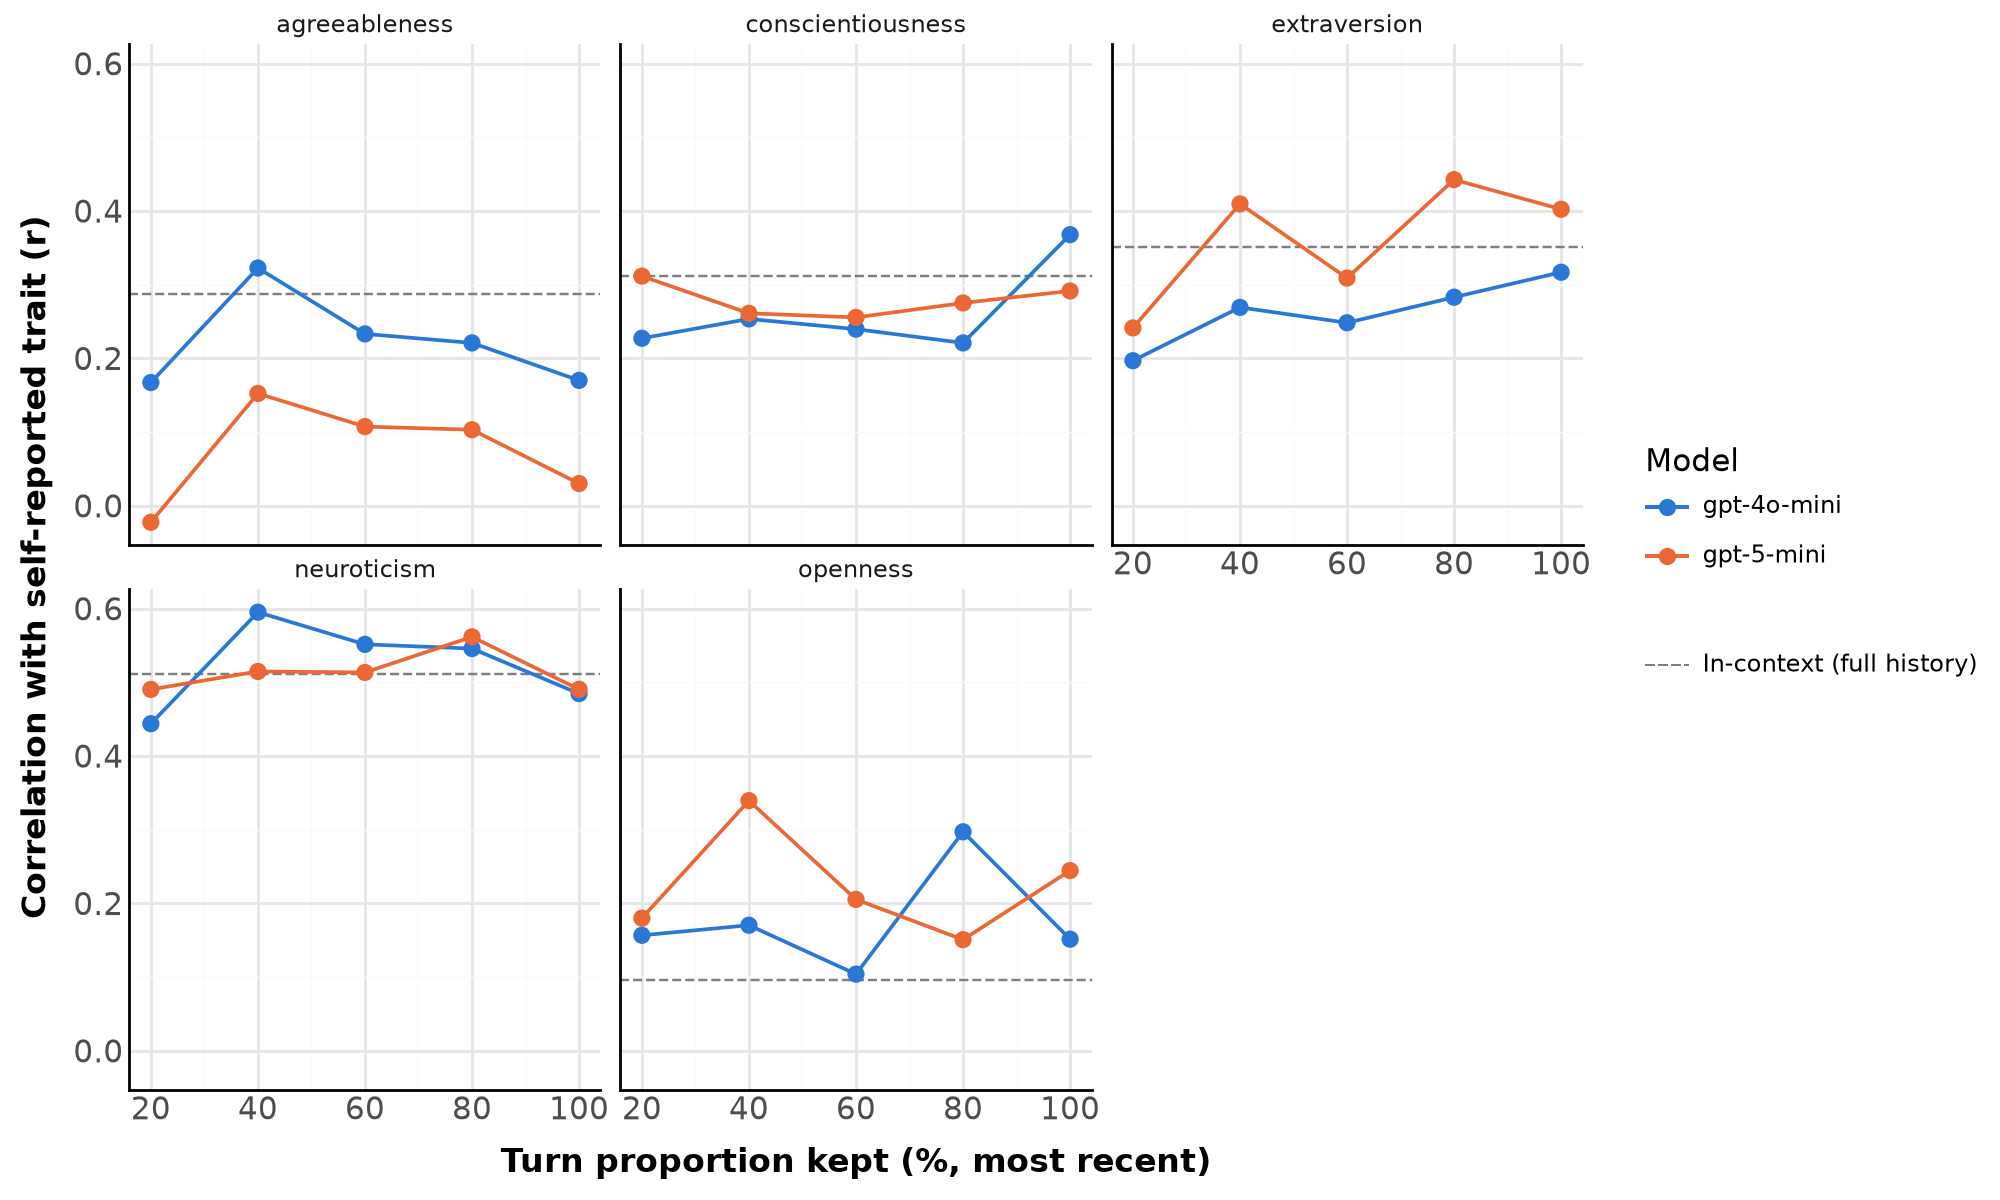

In [6]:
import glob
import re

import pandas as pd
import plotnine as p9
from scipy.stats import pearsonr

from utils import TRAIT_TO_OUTCOME

MODEL_LABELS = {"gpt4omini": "gpt-4o-mini", "gpt5mini": "gpt-5-mini"}
MODEL_COLORS = {"gpt-4o-mini": "#2a78d6", "gpt-5-mini": "#eb6834"}

records = []
for path in sorted(glob.glob("ds4ud/results/assessments_summary_plain_ds4ud_tp*l_gpt*.csv")):
    turn_proportion, model_tag = re.search(r"tp(\d+)l_(gpt\w+)\.csv", path).groups()
    if model_tag not in MODEL_LABELS:
        continue

    assessments = pd.read_csv(path).rename(columns={"user_id": "person_id"})
    assessments["person_id"] = assessments["person_id"].astype(str)
    merged = pd.merge(
        outcome_table, 
        assessments, 
        on="person_id"
    )

    for trait, outcome in TRAIT_TO_OUTCOME.items():
        res = pearsonr(merged[outcome], merged[f"assessed_{trait}"])
        ci_low, ci_high = res.confidence_interval()
        records.append({
            "turn_proportion": int(turn_proportion),
            "model": MODEL_LABELS[model_tag],
            "trait": trait,
            "r": res.statistic,
            "p": res.pvalue,
            "CI.low": ci_low,
            "CI.high": ci_high,
            "N": len(merged),
        })

performance = pd.DataFrame(records)

(
    p9.ggplot(
        data=performance, 
        mapping=p9.aes(
            x="turn_proportion", 
            y="r", 
            color="model"
        )
    ) +
    p9.geom_hline(
        data=results,
        mapping=p9.aes(yintercept="r", linetype="'In-context (full history)'"),
        color="gray",
    ) +
    # p9.geom_errorbar(
    #     mapping=p9.aes(ymin="CI.low", ymax="CI.high"),
    #     width=5,
    #     alpha=0.4,
    # ) +
    p9.geom_line(size=0.75) +
    p9.geom_point(size=2.5) +
    p9.facet_wrap("~trait") +
    p9.scale_color_manual(values=MODEL_COLORS) +
    p9.scale_linetype_manual(values={"In-context (full history)": "dashed"}) +
    p9.labs(
        x="Turn proportion kept (%, most recent)",
        y="Correlation with self-reported trait (r)",
        color="Model",
        linetype="",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(10, 6),
        axis_line=p9.element_line(),
        axis_title=p9.element_text(size=12, weight="bold"), 
        axis_text=p9.element_text(size=11)
    )
)

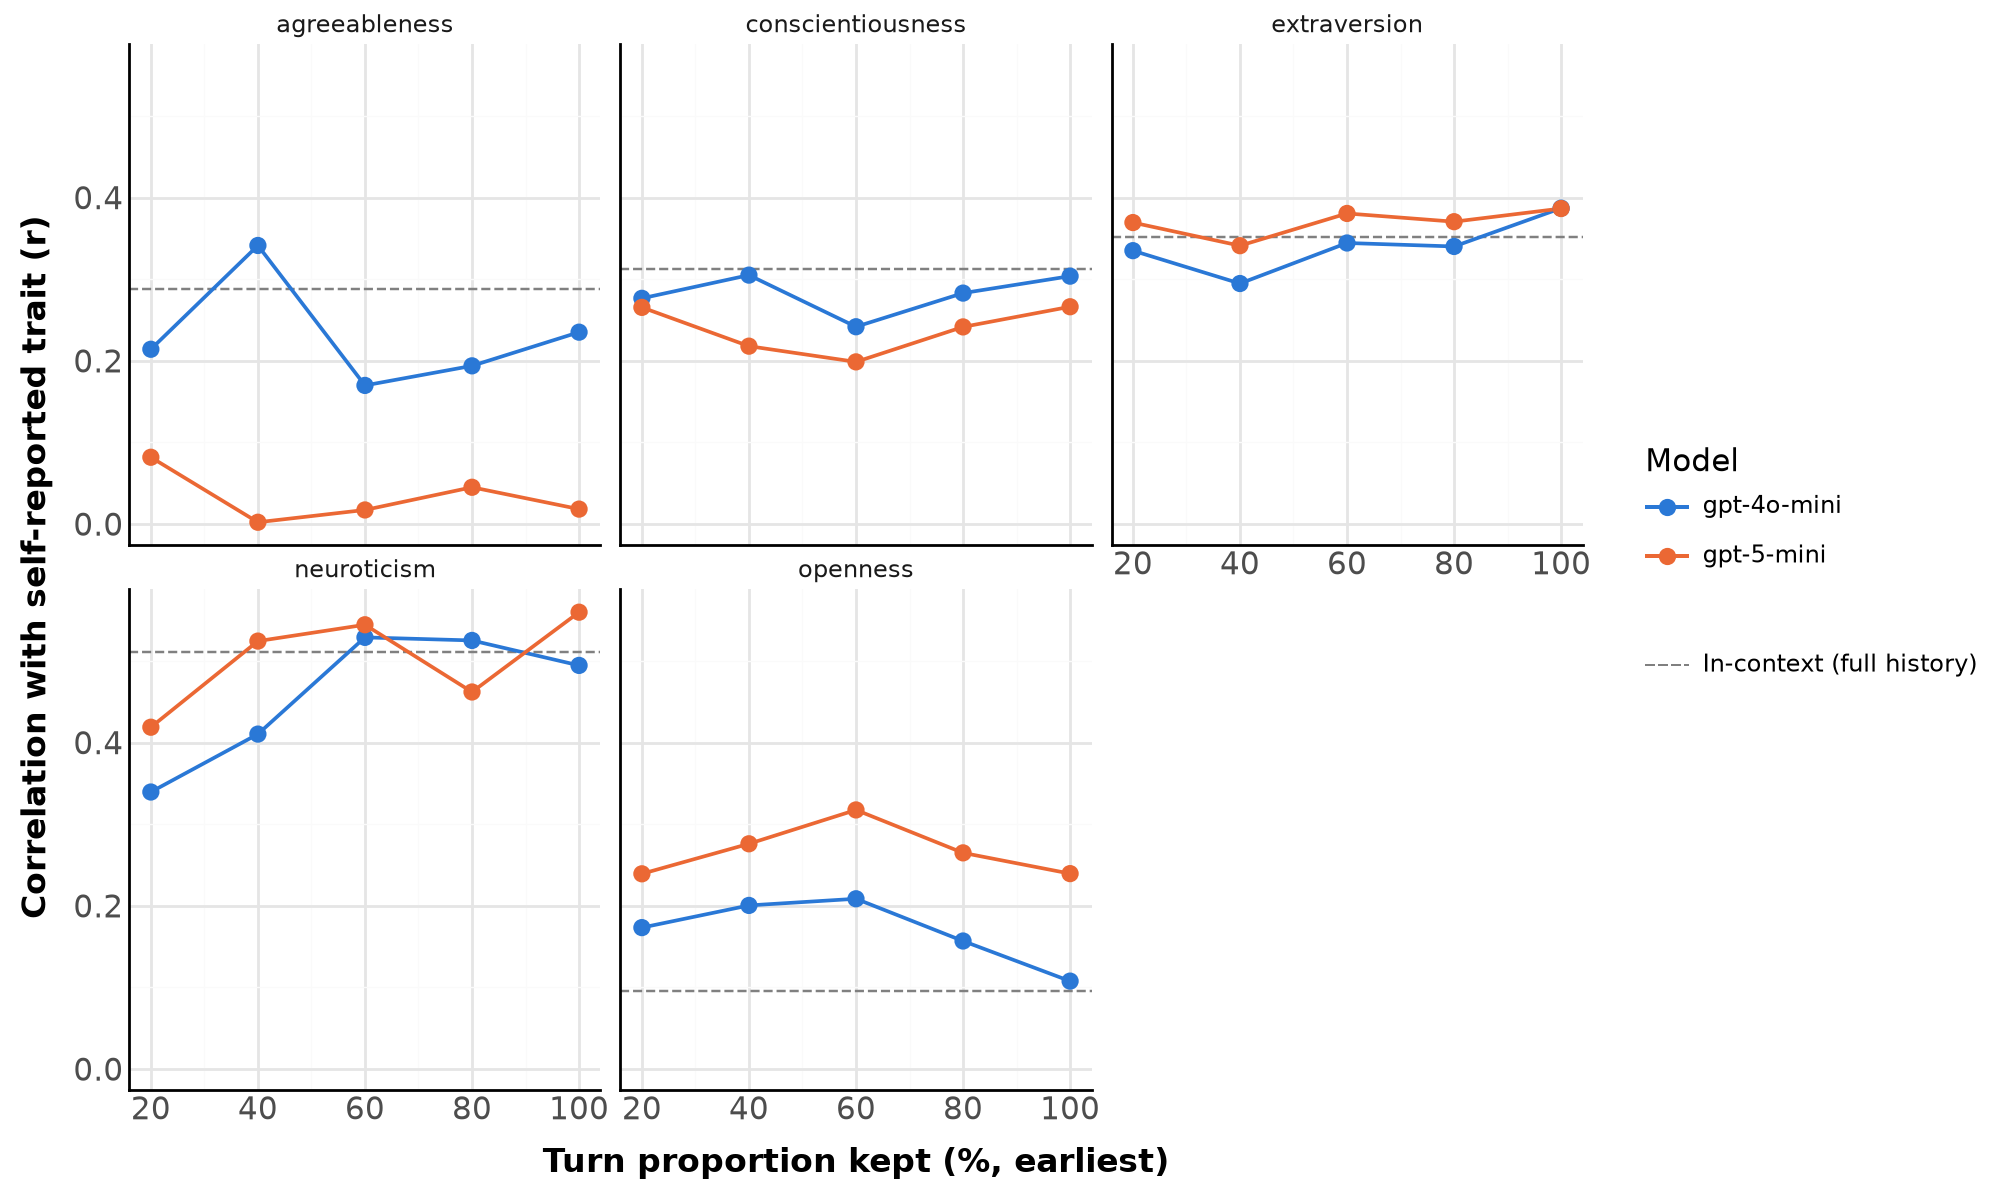

In [7]:
records = []
for path in sorted(glob.glob("ds4ud/results/assessments_summary_plain_ds4ud_tp*e_gpt*.csv")):
    turn_proportion, model_tag = re.search(r"tp(\d+)e_(gpt\w+)\.csv", path).groups()
    if model_tag not in MODEL_LABELS:
        continue

    assessments = pd.read_csv(path).rename(columns={"user_id": "person_id"})
    assessments["person_id"] = assessments["person_id"].astype(str)
    merged = pd.merge(
        outcome_table, 
        assessments, 
        on="person_id"
    )

    for trait, outcome in TRAIT_TO_OUTCOME.items():
        res = pearsonr(merged[outcome], merged[f"assessed_{trait}"])
        ci_low, ci_high = res.confidence_interval()
        records.append({
            "turn_proportion": int(turn_proportion),
            "model": MODEL_LABELS[model_tag],
            "trait": trait,
            "r": res.statistic,
            "p": res.pvalue,
            "CI.low": ci_low,
            "CI.high": ci_high,
            "N": len(merged),
        })

performance_earliest = pd.DataFrame(records)

(
    p9.ggplot(
        data=performance_earliest, 
        mapping=p9.aes(
            x="turn_proportion", 
            y="r", 
            color="model"
        )
    ) +
    p9.geom_hline(
        data=results,
        mapping=p9.aes(yintercept="r", linetype="'In-context (full history)'"),
        color="gray",
    ) +
    # p9.geom_errorbar(
    #     mapping=p9.aes(ymin="CI.low", ymax="CI.high"),
    #     width=5,
    #     alpha=0.4,
    # ) +
    p9.geom_line(size=0.75) +
    p9.geom_point(size=2.5) +
    p9.facet_wrap("~trait") +
    p9.scale_color_manual(values=MODEL_COLORS) +
    p9.scale_linetype_manual(values={"In-context (full history)": "dashed"}) +
    p9.labs(
        x="Turn proportion kept (%, earliest)",
        y="Correlation with self-reported trait (r)",
        color="Model",
        linetype="",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(10, 6),
        axis_line=p9.element_line(),
        axis_title=p9.element_text(size=12, weight="bold"), 
        axis_text=p9.element_text(size=11)
    )
)